# Karstnet - basics

This notebooks exposes the basics of the `karstnet` package.


In [1]:
import karstnet as kn
print(f'Karsnet version: {kn.__version__}')

Karsnet version: 1.4.6


## Example
In this exemple, a simple 2d graph is considered with some nodes of degree 2, three cycles including one looping branch (nodes 5-9-10), and 2 connected components. This permits to test : 
* the functionning of graph simplification : (most of the) nodes of degrees 2 are removed and the topology is preserved
* the computation of tortuosity in case of looping branch (which should be ignored as the real distance is nul between the starting and ending points)
* the functionning in case of disconnected parts



This network contains 2 connected components
   This network contains 1 looping branch.es. 
   Tortuosity is infinite on a looping branch. 
   The looping branches are not considered for the mean tortuosity computation.



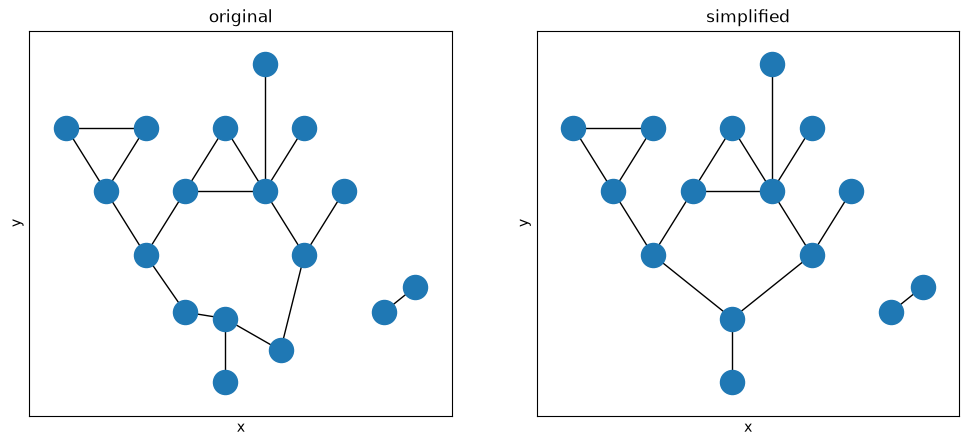

In [2]:
# The dictionary of nodes of the graph
# - "key : value" corresponds to "node label: node position"
# Note:  the node label may be an integer or a string
nodes = {
     1 : ( 0  , 0  ), 
     2 : ( 0  , 1  ), 
     3 : (-1  , 2  ), 
     4 : ( 1  , 2  ),
     5 : (-1.5, 3  ), 
     6 : (-0.5, 3  ), 
     7 : ( 0.5, 3  ), 
     8 : ( 1.5, 3  ),
     9 : (-2  , 4  ), 
    10 : (-1  , 4  ), 
    11 : ( 0  , 4  ), 
    12 : ( 1  , 4  ), 
    'x': ( 0.5, 5  ),
    14 : (-0.5, 1.1), 
    15 : ( 0.7, 0.5),
    16 : ( 2  , 1.1), 
    17 : ( 2.4, 1.5)
}

# The list of edges connecting the nodes
# Note: and edge is an unordered pair, i.e. 
#   "(label1, label2)" and "(label2, label1)" describe the same edge)
edges = [
    ( 1,  2 ), 
    ( 2, 15 ), 
    (15,  4 ), 
    ( 3,  5 ), 
    ( 3,  6 ), 
    ( 4,  7 ),
    ( 6,  7 ), 
    ( 6, 11 ),
    ( 4,  8 ), 
    ( 5,  9 ), 
    ( 5, 10 ), 
    ( 7, 11 ), 
    ( 7, 12 ), 
    ( 7, 'x'),
    ( 2, 14 ),
    (14,  3 ),
    ( 9, 10 ), 
    (16, 17 )
]

# Creation of an instance kg of the KGraph object using karstnet
kg = kn.KGraph(edges, nodes)

# Simple map view of original data (left) and simplified graph (right)
kg.plot()

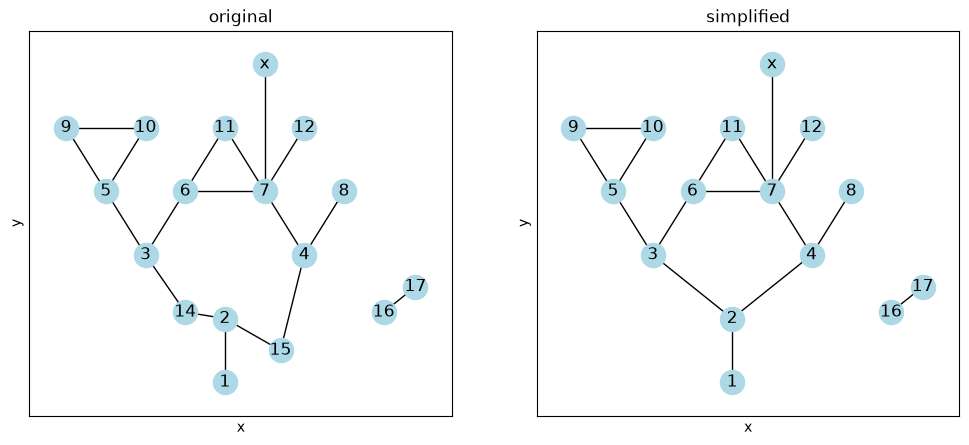

In [3]:
kg.plot(with_labels=True, node_color='lightblue')

## KGraph and networkX

The instance `kg` of the `KGraph` (class) being generated, two attributes are available wich are both `networkx.Graph` objects :
- `kg.graph` : the original graph
- `kg.graph_simpl` : the simplified graph, obtained by essentially removing all nodes of degree 2 (except in loops), so that the topology is preserved.

### Reference 
- Collon et al. (2017). *Statistical metrics for the characterization of karst network geometry and topology*, Geomorphology,
(https://doi.org/10.1016/j.geomorph.2017.01.034)


### Note
A `KGraph` object can be instantiated from a `networkx.Graph` object with position ('pos') as node attributes.



This network contains 2 connected components
   This network contains 1 looping branch.es. 
   Tortuosity is infinite on a looping branch. 
   The looping branches are not considered for the mean tortuosity computation.

Karstnet graph successfully created from networkx graph !



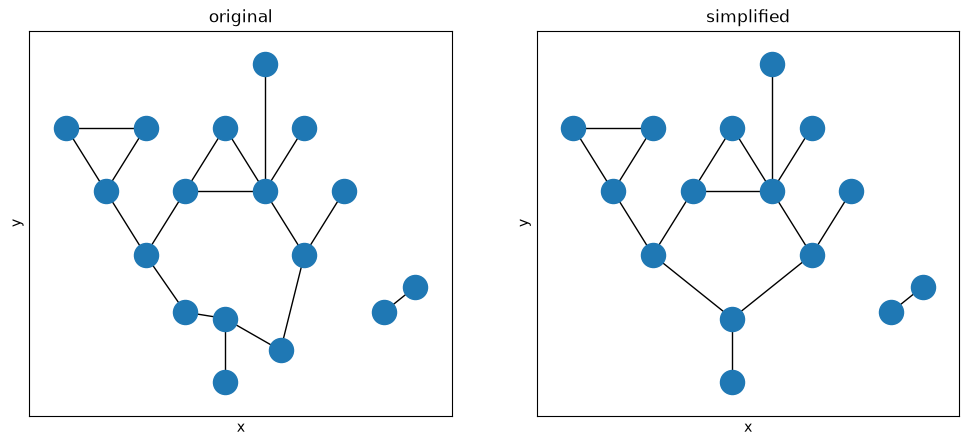

In [4]:
# Equivalently, with `nodes` and `edges` defined above:

import networkx as nx

g = nx.Graph() # instantiate a networkx.Graph object
g.add_nodes_from(nodes.keys()) # add nodes
nx.set_node_attributes(g, nodes, 'pos') # set node position
g.add_edges_from(edges) # add edges

kg2 = kn.from_networkx(g, pos_attr='pos') # instantiate a KGraph object from the networkx graph
kg2.plot()

## Using some possibilities of Networkx library

All functions and algorithms of `NetworkX` are applicable (see : https://networkx.github.io/documentation/stable/reference/functions.html) on `kg.graph` and `kg.graph_simpl`.

Let's demonstrate it to you with some examples...

In [5]:
import networkx as nx

In [6]:
# Compute the number of nodes
nb_nodes = kg.graph.number_of_nodes()
nb_nodes_simple = kg.graph_simpl.number_of_nodes()
print ("Number of nodes in the original graph : ", nb_nodes,
      "\nNumber of nodes in the simplified graph : ", nb_nodes_simple)

Number of nodes in the original graph :  17 
Number of nodes in the simplified graph :  15


In [7]:
# Compute the number of edges
nb_edges = kg.graph.number_of_edges()
nb_edges_simple = kg.graph_simpl.number_of_edges()
print ("Number of edges in the original graph : ", nb_edges,
      "\nNumber of edges in the simplified graph : ", nb_edges_simple)

Number of edges in the original graph :  18 
Number of edges in the simplified graph :  16


In [8]:
# Compute the density (number of edges / maximal number of edges)
dens = nx.density(kg.graph)
print("Density (original graph) :", dens)
#dens = k.graph.density()
#dens_simple = k.graph_simpl.density()
#print ("Number of edges in the complete graph : ", dens,
 #     "\nNumber of edges in the simplified graph : ", dens_simple)

Density (original graph) : 0.1323529411764706


In [9]:
# Number of selfloop(s)
nb_selfloops = nx.number_of_selfloops(kg.graph)
print("Number of selfloop(s) : ", nb_selfloops)

Number of selfloop(s) :  0


#### Connectivity 

In [10]:
# Number of connected components
nb_connected_components = nx.number_connected_components(kg.graph)
print ("Number of connected components : ", nb_connected_components)

Number of connected components :  2


In [11]:
# Number of cycles : nb_edges - nb_nodes + nb_connected_components
nb_cycles = nb_edges - nb_nodes + nb_connected_components
print ("Number of cycles : ", nb_cycles)

Number of cycles :  3


## Basic analysis and Howard's parameters
All basic networks analysis (number of edges, connected components, cycles, extremities and junction nodes) and the three Howard's parameters (alpha, beta, gamma) as defined in : 

- Howard, A. D., Keetch, M. E., & Vincent, C. L. (1970). **Topological and geometrical properties of braided patterns**, Water Resources Research, 6(6), 1674–1688

are available thanks to the method `basic_analysis()`.

In [12]:
kg.basic_analysis()


This network (original graph) contains :
     17 nodes (stations) and  18 edges.
 On the simplified graph, there are :
     15 nodes (stations) and  16 edges,
     6 are extremity nodes (entries or exits) and
     6 are junction nodes.
There is/are 2 connected component.s and 3 cycle.s.


Howard's parameter are (Howard, 1970) : 
   alpha : 0.12 
   beta : 1.0666666666666667 
   gamma : 0.41025641025641024

Note that this computation considers the node of degree 2 necessary to loop preservations as Seed Nodes, in order to stay consistent with Howard's illustrations.


{'alpha': 0.12, 'beta': 1.0666666666666667, 'gamma': 0.41025641025641024}

## Graph statistics
The class `KGraph` contains methods to compute global statistics of the network, described in the table below. The statistics marked with (*) are computed on the simplified graph. The method `characterize_graph` computes all the statistics and stores them in a dictionary (key given in the table).


| method                    | key                        | description |
|:------                    |:-----                      |:------------|
|`mean_length`              |'mean length'               | mean length of the branches                                                  |
|`coef_variation_length`    |'cv length'                 | coefficient of variation (std. dev. / mean) of branch length                 |
|`length_entropy`           |'length entropy'            | entropy of branch length                                                     |
|`mean_tortuosity`          |'tortuosity'                | mean tortuosity of branches                                                  |
|`orientation_entropy`      |'orientation entropy'       | entropy of edges orientation (2d, azimuth)                                   |
|`orientation3d_entropy`    |'orientation 3d entropy'    | entropy of edges orientation (3d, azimuth and dip)                           |
|`average_SPL`              |'aspl'                      | average shortest path length (*)                                             |
|`central_point_dominance`  |'cpd'                       | central point dominance (*)                                                  |
|`mean_degree_and_CV`       |'mean degree'               | mean of node degrees (*)                                                     |
|                           |'cv degree'                 | coefficient of variation of node degrees (*)                                 |
|`correlation_vertex_degree`|'correlation vertex degree' | correlation of node degrees over pairs of connected nodes (assortativity) (*)|

*Note. A branch of a graph is a path where all the nodes except the two extremities are nodes of degree 2. The tortuosity of a branch is the ratio of its length over the distance between its two extremities.*

**Remark.** By default, "orientation 3d entropy" is not computed, set parameter `compute_orientation_3d_entropy=True` to compute it.


In [13]:
# Computes the statistics of the graph
results = kg.characterize_graph(verbose=True)
# results = kg.characterize_graph(compute_orientation_3d_entropy=True, verbose=True)

Computing:
 - mean length, cv length, length entropy, mean tortuosity

 - orientation entropy
 - aspl, cpd, md, cv degree, cvd

Results:
--------------------------------------
 mean length               =  1.504
 cv length                 =  0.497
 length entropy            =  0.613
 tortuosity                =  1.168
 orientation entropy       =  0.612
 aspl                      =  2.444
 cpd                       =  0.251
 mean degree               =  2.133
 cv degree                 =  0.557
 correlation vertex degree = -0.250
--------------------------------------


## Computing stereonet 

*Contribution of P. Vernant (2019).*

This functionality uses the `mplstereonet` package (https://github.com/joferkington/mplstereonet) in order to reproduce the drawings proposed in Collon et al. 2017 (https://doi.org/10.1016/j.geomorph.2017.01.034). By default, density map values are weigthed by the real 3D length of the segments, while the Rose diagram is weigthed by the 2D projected lengths of segments 
on the horizontal plane. (To get Stereo and Rose diagram without weigthing by the lengths of the conduits, the option `weighted=False` can be used.)



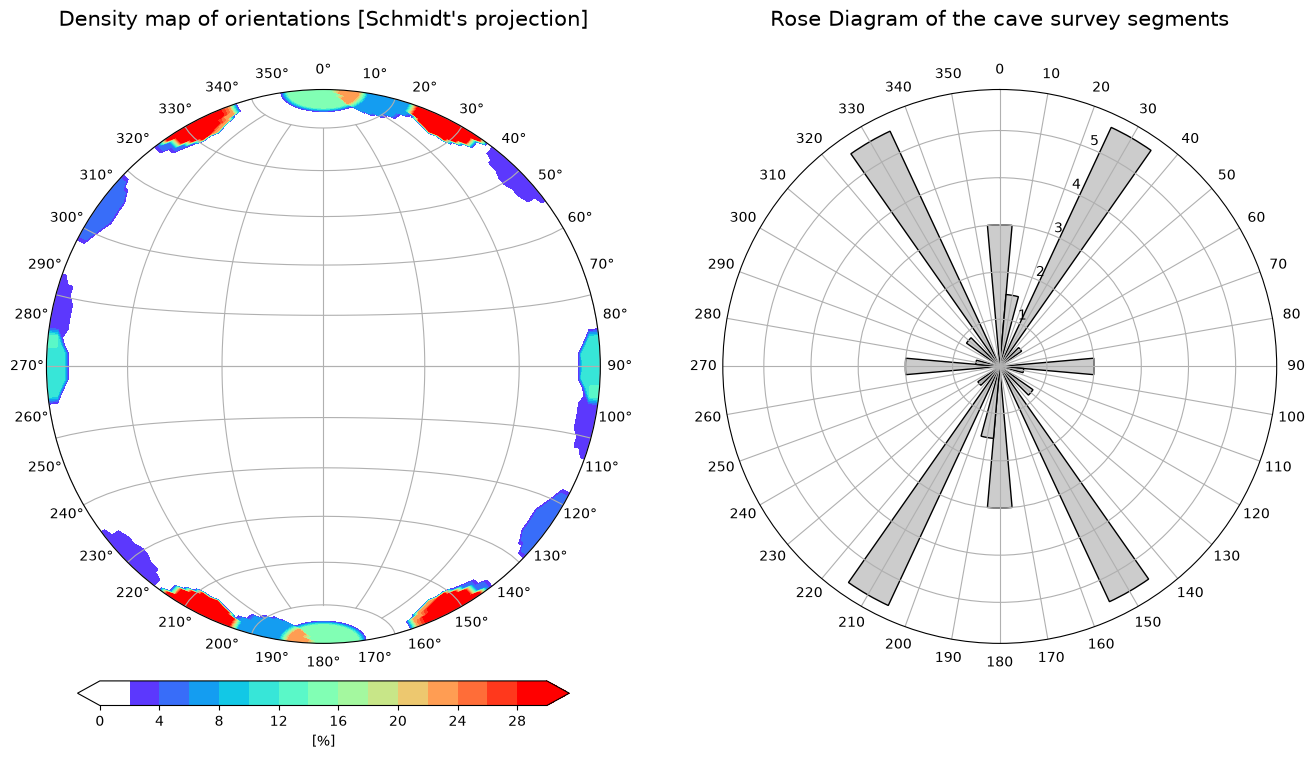

In [14]:
kg.stereo()